<a href="https://colab.research.google.com/github/Raksh1707/Naturalproject/blob/main/nlp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt

from collections import Counter

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud


# Download NLTK resources
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
complaints = [
    "My account was charged twice for the same transaction.",
    "The ATM did not give me cash but the amount was deducted.",
    "I cannot login to my online banking account.",
    "My loan application has been pending for several weeks.",
    "The bank charged a very high processing fee for my loan.",
    "My debit card stopped working suddenly.",
    "The mobile banking application keeps crashing.",
    "I did not receive the money transferred to my account.",
    "There is an unknown transaction on my bank statement.",
    "The interest rate on my loan is higher than expected.",
    "I forgot my internet banking password and cannot reset it.",
    "My account balance has not been updated after a deposit.",
    "The ATM retained my debit card.",
    "My credit card payment was not reflected in my account.",
    "The bank charged me an unexpected maintenance fee.",
    "I am unable to transfer money through online banking.",
    "My loan EMI was deducted twice this month.",
    "The bank has not processed my loan application.",
    "I received a suspicious transaction notification.",
    "My account has been blocked without explanation.",
    "The mobile banking app is extremely slow.",
    "My cheque deposit is still not reflected in my account.",
    "I cannot download my bank statement online.",
    "The ATM charged my account but did not dispense cash.",
    "My loan repayment amount is incorrect.",
    "I want to report an unauthorized withdrawal.",
    "Online banking is showing an incorrect account balance.",
    "The bank charged extra fees for transferring money.",
    "My debit card has expired and I have not received a replacement.",
    "The customer service team has not responded to my complaint.",
    "I cannot add a beneficiary in online banking.",
    "My loan interest rate was changed without proper information.",
    "The ATM is not accepting my card.",
    "I received the wrong amount after making a cash withdrawal.",
    "My account statement contains an unfamiliar payment.",
    "The banking application does not open on my phone.",
    "My loan approval is taking too long.",
    "Money was deducted from my account during an unsuccessful transaction.",
    "I cannot update my personal details through the banking portal.",
    "The bank charged me a penalty that I was not expecting.",
    "My online transfer failed but the money was deducted.",
    "I need help with my savings account.",
    "The bank has not credited my refund yet.",
    "My account was debited for a transaction I did not make.",
    "The ATM cash withdrawal limit is causing problems.",
    "I cannot access my account after changing my phone number.",
    "The loan documents were submitted but there is no update.",
    "My banking password reset link is not working.",
    "The bank deducted an incorrect EMI amount.",
    "I am unhappy with the response from customer support."
]


In [4]:
df = pd.DataFrame({
    "Complaint": complaints
})

print("==================================================")
print("BANKING COMPLAINT DATASET")
print("==================================================")

print(df.head())

print("\nTotal Complaints:", len(df))

BANKING COMPLAINT DATASET
                                           Complaint
0  My account was charged twice for the same tran...
1  The ATM did not give me cash but the amount wa...
2       I cannot login to my online banking account.
3  My loan application has been pending for sever...
4  The bank charged a very high processing fee fo...

Total Complaints: 50


In [5]:
def categorize_complaint(text):

    text = text.lower()

    # Transaction related
    if any(word in text for word in [
        "transaction",
        "transfer",
        "payment",
        "debited",
        "deducted",
        "refund",
        "withdrawal"
    ]):
        return "Transactions"

    # Loan related
    elif any(word in text for word in [
        "loan",
        "emi",
        "interest rate",
        "repayment",
        "approval"
    ]):
        return "Loans"

    # Online banking related
    elif any(word in text for word in [
        "online banking",
        "mobile banking",
        "banking application",
        "banking app",
        "login",
        "password",
        "beneficiary",
        "banking portal"
    ]):
        return "Online Banking"

    # Account related
    elif any(word in text for word in [
        "account",
        "balance",
        "statement",
        "personal details",
        "savings account"
    ]):
        return "Account Management"

    # ATM / card related
    elif any(word in text for word in [
        "atm",
        "debit card",
        "credit card",
        "cash withdrawal"
    ]):
        return "ATM/Card"

    # Customer service
    elif any(word in text for word in [
        "customer service",
        "customer support",
        "complaint"
    ]):
        return "Customer Service"

    else:
        return "Other"


df["Category"] = df["Complaint"].apply(
    categorize_complaint
)


print("\n==================================================")
print("COMPLAINT CATEGORIES")
print("==================================================")

print(df[["Complaint", "Category"]].head(10))




COMPLAINT CATEGORIES
                                           Complaint        Category
0  My account was charged twice for the same tran...    Transactions
1  The ATM did not give me cash but the amount wa...    Transactions
2       I cannot login to my online banking account.  Online Banking
3  My loan application has been pending for sever...           Loans
4  The bank charged a very high processing fee fo...           Loans
5            My debit card stopped working suddenly.        ATM/Card
6     The mobile banking application keeps crashing.  Online Banking
7  I did not receive the money transferred to my ...    Transactions
8  There is an unknown transaction on my bank sta...    Transactions
9  The interest rate on my loan is higher than ex...           Loans


In [8]:
stop_words = set(
    stopwords.words("english")
)


def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


df["Clean_Complaint"] = df[
    "Complaint"
].apply(clean_text)


print("\n==================================================")
print("PREPROCESSED DATA")
print("==================================================")

print(
    df[
        ["Complaint", "Clean_Complaint"]
    ].head()
)





PREPROCESSED DATA
                                           Complaint  \
0  My account was charged twice for the same tran...   
1  The ATM did not give me cash but the amount wa...   
2       I cannot login to my online banking account.   
3  My loan application has been pending for sever...   
4  The bank charged a very high processing fee fo...   

                          Clean_Complaint  
0       account charged twice transaction  
1           atm give cash amount deducted  
2     cannot login online banking account  
3  loan application pending several weeks  
4   bank charged high processing fee loan  


In [9]:
# ----------------------------------------------------------
# Step 6: Identify Frequent Banking Issues
# ----------------------------------------------------------

all_words = " ".join(
    df["Clean_Complaint"]
).split()

word_frequency = Counter(
    all_words
)

top_issues = word_frequency.most_common(
    15
)


print("\n==================================================")
print("FREQUENT BANKING ISSUES")
print("==================================================")

for word, count in top_issues:

    print(
        word,
        "->",
        count,
        "mentions"
    )



FREQUENT BANKING ISSUES
account -> 14 mentions
banking -> 10 mentions
loan -> 9 mentions
bank -> 9 mentions
charged -> 6 mentions
cannot -> 6 mentions
online -> 6 mentions
transaction -> 5 mentions
atm -> 5 mentions
deducted -> 5 mentions
card -> 5 mentions
money -> 5 mentions
cash -> 4 mentions
amount -> 4 mentions
application -> 4 mentions


In [10]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(
    df["Clean_Complaint"]
)

y = df["Category"]


# ----------------------------------------------------------
# Step 8: Split Dataset
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)



In [11]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

print("\n==================================================")
print("MODEL TRAINED SUCCESSFULLY")
print("==================================================")


MODEL TRAINED SUCCESSFULLY


In [12]:
y_pred = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nModel Accuracy:")
print(
    round(accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)



Model Accuracy:
46.15 %

Classification Report:
                    precision    recall  f1-score   support

          ATM/Card       0.00      0.00      0.00         1
Account Management       0.00      0.00      0.00         2
  Customer Service       0.00      0.00      0.00         1
             Loans       0.00      0.00      0.00         2
    Online Banking       1.00      0.50      0.67         2
      Transactions       0.42      1.00      0.59         5

          accuracy                           0.46        13
         macro avg       0.24      0.25      0.21        13
      weighted avg       0.31      0.46      0.33        13



In [13]:
new_complaint = [
    "My online banking transfer failed and money was deducted."
]

clean_new_complaint = clean_text(
    new_complaint[0]
)

new_vector = vectorizer.transform(
    [clean_new_complaint]
)

prediction = model.predict(
    new_vector
)


print("\n==================================================")
print("NEW COMPLAINT CLASSIFICATION")
print("==================================================")

print(
    "Complaint:",
    new_complaint[0]
)

print(
    "Predicted Category:",
    prediction[0]
)


NEW COMPLAINT CLASSIFICATION
Complaint: My online banking transfer failed and money was deducted.
Predicted Category: Transactions


In [14]:
category_count = df[
    "Category"
].value_counts()


print("\n==================================================")
print("BANKING COMPLAINT ANALYTICAL REPORT")
print("==================================================")

print(
    "\nTotal Complaints:",
    len(df)
)

print("\nComplaints by Category:")

print(category_count)

print(
    "\nMost Common Complaint Category:",
    category_count.idxmax()
)

print(
    "Number of Complaints:",
    category_count.max()
)


BANKING COMPLAINT ANALYTICAL REPORT

Total Complaints: 50

Complaints by Category:
Category
Transactions          19
Online Banking         9
Loans                  7
Account Management     7
ATM/Card               4
Other                  2
Customer Service       2
Name: count, dtype: int64

Most Common Complaint Category: Transactions
Number of Complaints: 19


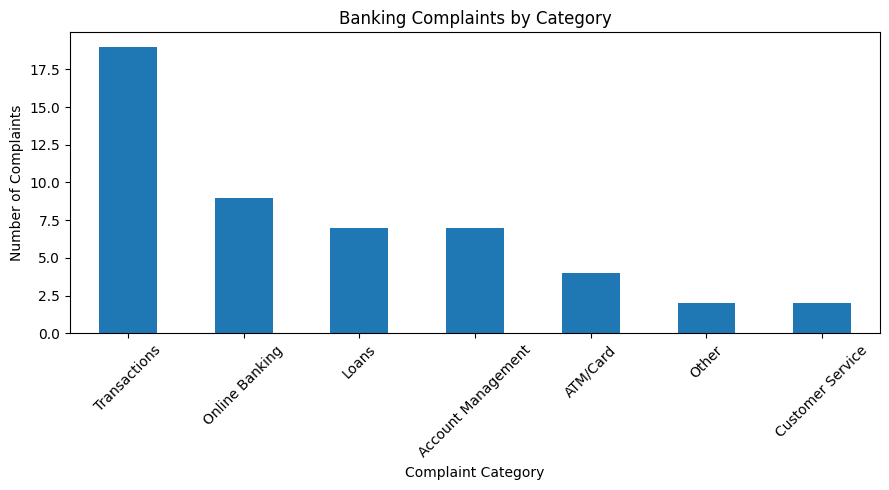

In [15]:
plt.figure(
    figsize=(9, 5)
)

category_count.plot(
    kind="bar"
)

plt.title(
    "Banking Complaints by Category"
)

plt.xlabel(
    "Complaint Category"
)

plt.ylabel(
    "Number of Complaints"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

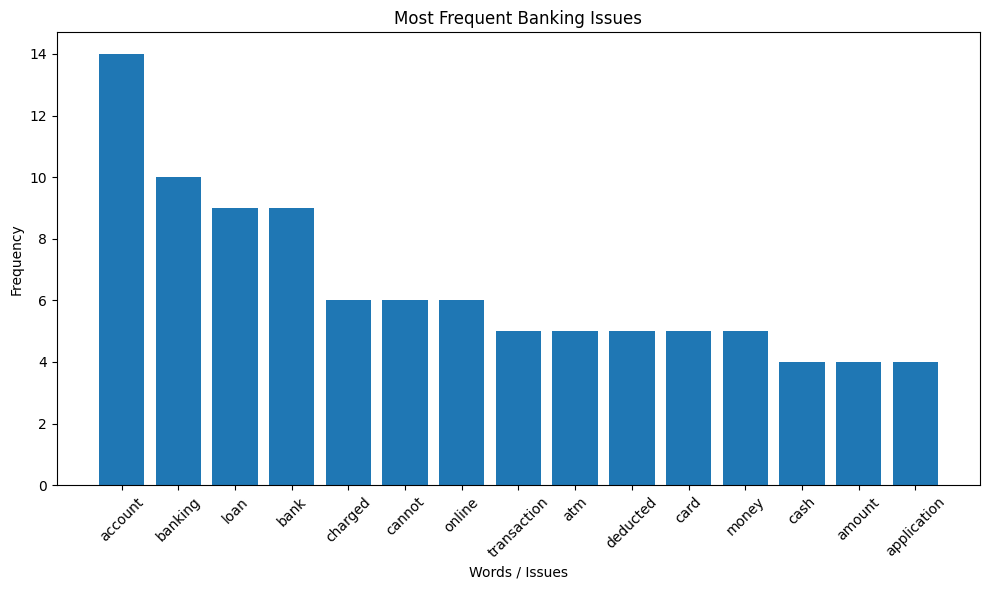

In [16]:
words = [
    item[0]
    for item in top_issues
]

counts = [
    item[1]
    for item in top_issues
]

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    words,
    counts
)

plt.title(
    "Most Frequent Banking Issues"
)

plt.xlabel(
    "Words / Issues"
)

plt.ylabel(
    "Frequency"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


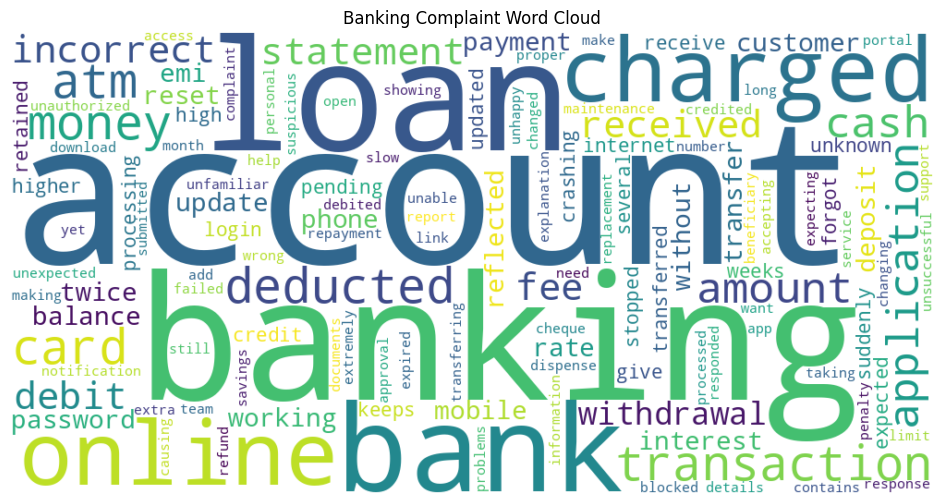

In [17]:
all_text = " ".join(
    df["Clean_Complaint"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_text)

plt.figure(
    figsize=(12, 6)
)

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Banking Complaint Word Cloud"
)

plt.show()


In [18]:
df.to_csv(
    "Banking_Complaint_Analysis.csv",
    index=False
)

category_count.to_csv(
    "Complaint_Category_Summary.csv"
)

print("\n==================================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("==================================================")

print(
    "Detailed results saved as:"
)

print(
    "Banking_Complaint_Analysis.csv"
)

print(
    "Complaint_Category_Summary.csv"
)


PROJECT COMPLETED SUCCESSFULLY
Detailed results saved as:
Banking_Complaint_Analysis.csv
Complaint_Category_Summary.csv
